In [1]:
import json
# import plotly.express as px
import pandas as pd
# import openpyxl
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Tender schedule with starting point

In [64]:
with open('Deterministic_results_F_Q_I_S_30_demand_capacity.json') as json_file:
    F_results = json.load(json_file)


In [65]:
# Search results by keyword for F (tender schedules)
# List of keywords to search for
keywords_to_search = ["M"]

# Initialize a dictionary to store grouped results
grouped_results = {keyword: [] for keyword in keywords_to_search}

# Search for keywords in the JSON keys and group the results
for key, value in F_results.items():
    for keyword in keywords_to_search:
        if keyword in key:
            grouped_results[keyword].append({key: value})


In [66]:
#filter for F and X, to show vaccines allocated per tender

# Extract the 'M' group
m_group = grouped_results.get('M', [])

# Filter dictionaries starting with 'X' or 'F' and exclude those with 'X_tilde'
filtered_dicts = [
    entry for entry in m_group
    if any((key.startswith(('X[', 'F')) and 'X_tilde' not in key) for key in entry)
       and not all(value == 0 for key, value in entry.items())
       and all('HPV' not in key for key in entry)
]

In [56]:
#group the data into X and F

# Function to group items by key start value
def group_by_start_value(items):
    grouped_data = {}

    for item in items:
        key = list(item.keys())[0]  # Extract the key from the dictionary
        start_value = key[0]  # Get the first character of the key
        if start_value not in grouped_data:
            grouped_data[start_value] = []
        grouped_data[start_value].append(item)

    return grouped_data

# Group the data
result = group_by_start_value(filtered_dicts)

result


{'X': [{'X[MR,Serum_Institute,18]': 257727161.40678653},
  {'X[MR,Serum_Institute,6]': 317699068.65048504},
  {'X[MMR,Serum_Institute,33]': 12233333.241939545},
  {'X[MR,Biological_E,24]': 43881191.523274325},
  {'X[MR,Serum_Institute,1]': 356699776.0},
  {'X[M,PT_Bio,19]': 22566015.625},
  {'X[MR,Biological_E,20]': 43881806.89800462},
  {'X[M,PT_Bio,15]': 22556250.0},
  {'X[MR,Biological_E,26]': 43881160.75452248},
  {'X[MR,Serum_Institute,12]': 257137311.06195518},
  {'X[M,PT_Bio,8]': 20800000.0},
  {'X[M,PT_Bio,26]': 22566671.752929688},
  {'X[MMR,Serum_Institute,17]': 12227343.75},
  {'X[MR,Biological_E,10]': 51579436.15018723},
  {'X[M,Serum_Institute,1]': 16280000.0},
  {'X[M,PT_Bio,3]': 11058838.617148433},
  {'X[MR,Serum_Institute,30]': 257685526.33568838},
  {'X[MR,Serum_Institute,13]': 300150000.0},
  {'X[MR,Serum_Institute,25]': 301566320.80078125},
  {'X[M,PT_Bio,31]': 22566666.507720947},
  {'X[MR,Biological_E,2]': 27807206.385922007},
  {'X[MR,Biological_E,5]': 147500000.

In [57]:
# create dictionary from F data from above
# Extracting information from the dictionary
data_list = []
for item in result['F']:
    key, value = list(item.items())[0]
    # print(key)
    tender = key.split('[', 1)[1].split(',', 1)[0]
    start, finish = eval(key.split('(', 1)[1].split(')', 1)[0])
    value = item[key]
    
    data_list.append({'Tender': tender, 'Start': start, 'Finish': finish, 'Value': value})

# Create a DataFrame
F_values_df = pd.DataFrame(data_list)
F_values_df = F_values_df[F_values_df.Tender == 'Measles']
F_values_df.Start = F_values_df.Start -1
# Display the DataFrame
F_values_df


,Tender,Start,Finish,Value
0,Measles,1,6,1.0
3,Measles,11,16,1.0
4,Measles,20,25,1.0
7,Measles,25,30,1.0
8,Measles,15,20,1.0
9,Measles,30,35,1.0
12,Measles,0,3,1.0
15,Measles,6,11,1.0


In [58]:

# Extracting data for the DataFrame
df_data = []
for entry in result['X']:
    key, value = entry.popitem()
    vaccine = key.split(',')[0][2:]
    producer = key.split(',')[1].strip()
    start = int(key.split(',')[2].split(']')[0])
    end = int(start)
    df_data.append({'Vaccine': vaccine, 'Producer': producer, 'Start': start, 'End': end, 'Value': value})

# Creating DataFrame
X_data = pd.DataFrame(df_data)

# Print the DataFrame
X_data


,Vaccine,Producer,Start,End,Value
0,MR,Serum_Institute,18,18,2.577272e+08
1,MR,Serum_Institute,6,6,3.176991e+08
2,MMR,Serum_Institute,33,33,1.223333e+07
3,MR,Biological_E,24,24,4.388119e+07
4,MR,Serum_Institute,1,1,3.566998e+08
...,...,...,...,...,...
112,MMR,Serum_Institute,13,13,1.213750e+07
113,MMR,Serum_Institute,16,16,1.224531e+07
114,MMR,Merck_Sharp,1,1,2.574979e+06
115,M,PT_Bio,5,5,1.909958e+07


In [59]:
X_data[X_data.Vaccine == "MMR"].sort_values(by='Start')

,Vaccine,Producer,Start,End,Value
81,MMR,Serum_Institute,1,1,1.354712e+07
114,MMR,Merck_Sharp,1,1,2.574979e+06
25,MMR,GSK,2,2,2.055629e+08
112,MMR,Serum_Institute,13,13,1.213750e+07
23,MMR,Serum_Institute,14,14,1.228125e+07
91,MMR,Serum_Institute,15,15,1.220938e+07
113,MMR,Serum_Institute,16,16,1.224531e+07
12,MMR,Serum_Institute,17,17,1.222734e+07
37,MMR,Serum_Institute,18,18,1.223633e+07
66,MMR,Serum_Institute,19,19,1.223184e+07


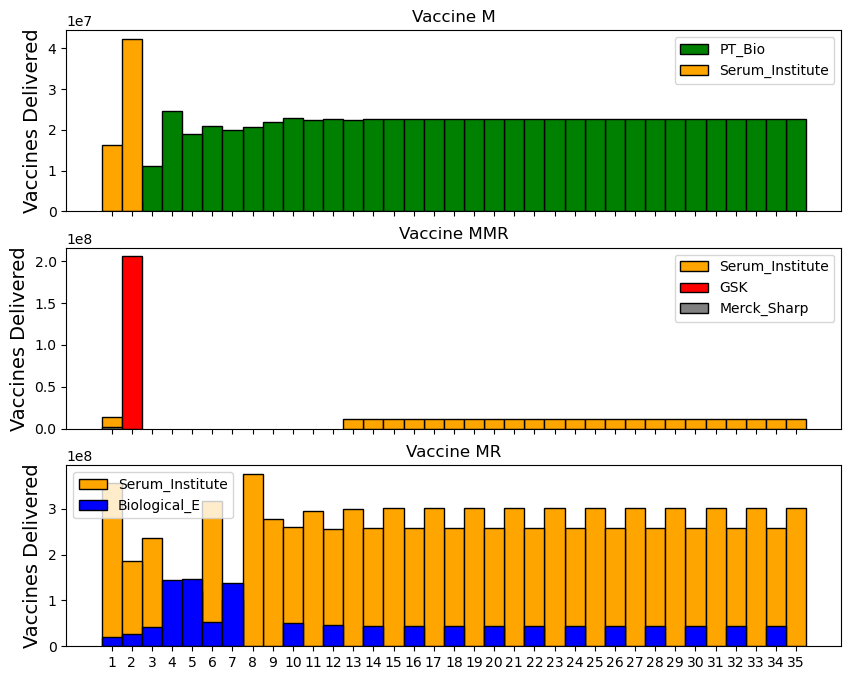

In [61]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Using DataFrame.insert() to add a column
F_values_df.insert(2, "Color", ['green', 'blue', 'orange', 'red', 'grey', 'purple','yellow','maroon'], True)

# Create subplots for each vaccine
fig, axs = plt.subplots(nrows=len(X_data['Vaccine'].unique()), figsize=(10, 8), sharex=True)

# Define unique colors for each producer
producer_colors = {'Biological_E': 'blue', 'Serum_Institute': 'orange', 'PT_Bio': 'green', 'GSK': 'red', 'Merck_Sharp':'grey'}

# Plot stacked bars for each vaccine
for i, (vaccine, group) in enumerate(X_data.groupby('Vaccine')):
    producers = group['Producer'].unique()
    
    for producer in producers:
        producer_data = group[group['Producer'] == producer]
        axs[i].bar(producer_data['Start'], producer_data['Value'], label=producer, bottom=np.zeros(len(producer_data)), width=1.0, edgecolor='black', linewidth=1, color=producer_colors.get(producer, 'gray'))

    axs[i].set_title(f'Vaccine {vaccine}')
    axs[i].set_ylabel('Vaccines Delivered', fontsize=14)
    axs[i].legend()
    

# Set x-axis ticks for each year
for ax in axs.flat:
    ax.set_xticks(np.arange(min(X_data['Start']), max(X_data['End']) + 1, 1))
    # ax.set_xlabel('Time (Start)')


# plt.suptitle('Measles vaccination by Vaccine/Producer')
plt.savefig('Deterministic_results_F_Q_I_S_30_with_mod.png', bbox_inches='tight', pad_inches=0.1)
plt.show()


In [82]:
#CHECK I levels
with open('Deterministic_results_F_Q_I_S_30_demand_capacity.json') as json_file:
    F_results = json.load(json_file)

    

# List of keywords to search for
keywords_to_search = ["I["]

# Initialize a dictionary to store grouped results
grouped_results = {keyword: [] for keyword in keywords_to_search}

# Search for keywords in the JSON keys and group the results
for key, value in F_results.items():
    for keyword in keywords_to_search:
        if keyword in key:
            grouped_results[keyword].append({key: value})


In [ ]:
# Extract the 'M' group
m_group = grouped_results.get('I[', [])

# Filter dictionaries starting with 'X' or 'F' and exclude those with 'X_tilde'
filtered_dicts = [
    entry for entry in m_group
    if ('MMR' in key for key in entry)
]

# filtered_dicts

In [84]:
import pandas as pd

data = [
    {'I[DTwP-Hib,7]': 0.0},
    {'I[Penta,0]': 12542.0},
    {'I[DTwP-Hib,6]': 0.0},
    {'I[HepB,29]': 0.0},
    {'I[DTwP,18]': 53097868.398522735},
]

# Extracting data and creating a DataFrame
df_data = []
for item in filtered_dicts:
    key, value = item.popitem()
    vaccine_start = key.find('I[') + 2
    vaccine_end = key.find(',', vaccine_start)
    year_start = vaccine_end + 1
    year_end = key.find(']', year_start)
    
    vaccine = key[vaccine_start:vaccine_end]
    year = key[year_start:year_end]
    
    df_data.append({'Vaccine': vaccine, 'Year': year, 'Value': value})

df = pd.DataFrame(df_data)

# Display the DataFrame
df


,Vaccine,Year,Value
0,DTwP-Hib,7,0.000000e+00
1,Penta,0,1.254200e+04
2,DTwP-Hib,6,0.000000e+00
3,HepB,29,0.000000e+00
4,DTwP,18,5.309787e+07
...,...,...,...
607,Hib,19,0.000000e+00
608,OPV,5,0.000000e+00
609,DTwP,22,5.308675e+07
610,DT,27,0.000000e+00


In [87]:
df[(df.Vaccine == "MMR") & (df.Value != 0)].sort_values(by='Year')

,Vaccine,Year,Value
534,MMR,10,24275000.0
494,MMR,11,12425000.0
177,MMR,2,166375000.0
82,MMR,3,140575000.0
136,MMR,4,115275000.0
347,MMR,5,91775000.0
279,MMR,6,75575000.0
301,MMR,7,56875000.0
588,MMR,8,47975000.0
335,MMR,9,37275000.0
